### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import plotly.express as px
from sklearn.preprocessing import StandardScaler

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [44]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [45]:
df.shape

(2240, 29)

In [46]:
df.dtypes

,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
MntWines,int64


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [48]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


- Датафрейм містить 2240 рядків та 29 колонок.
- Дані представлені числовими та категоріальними типами.
- Під час перевірки пропущених значень було виявлено 24 пропуски у колонці Income.

**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [49]:
df['Income'] = df['Income'].fillna(df['Income'].median())
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


Оскільки подальший аналіз буде виконуватися за допомогою алгоритмів кластеризації, видалення рядків було недоцільним, тому що це могло б призвести до втрати інформації про клієнтів.

Пропущені значення були замінені медіаною колонки Income.
Медіана була обрана замість середнього значення, оскільки вона є більш стійкою до викидів і великих значень доходу, які можуть вплинути на формування кластерів.

**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [50]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

In [51]:
df['Customer_Days'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days

In [52]:
df = df.drop('Dt_Customer', axis=1)

In [53]:
# One-hot encoding категоріальних колонок

df = pd.get_dummies(
    df,
    columns=['Education', 'Marital_Status'],
    drop_first=True
)

In [54]:
df.head()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,5524,1957,58138.0,0,0,58,635,88,546,172,...,True,False,False,False,False,False,True,False,False,False
1,2174,1954,46344.0,1,1,38,11,1,6,2,...,True,False,False,False,False,False,True,False,False,False
2,4141,1965,71613.0,0,0,26,426,49,127,111,...,True,False,False,False,False,False,False,True,False,False
3,6182,1984,26646.0,1,0,26,11,4,20,10,...,True,False,False,False,False,False,False,True,False,False
4,5324,1981,58293.0,1,0,94,173,43,118,46,...,False,False,True,False,False,True,False,False,False,False


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       2240 non-null   int64  
 1   Year_Birth               2240 non-null   int64  
 2   Income                   2240 non-null   float64
 3   Kidhome                  2240 non-null   int64  
 4   Teenhome                 2240 non-null   int64  
 5   Recency                  2240 non-null   int64  
 6   MntWines                 2240 non-null   int64  
 7   MntFruits                2240 non-null   int64  
 8   MntMeatProducts          2240 non-null   int64  
 9   MntFishProducts          2240 non-null   int64  
 10  MntSweetProducts         2240 non-null   int64  
 11  MntGoldProds             2240 non-null   int64  
 12  NumDealsPurchases        2240 non-null   int64  
 13  NumWebPurchases          2240 non-null   int64  
 14  NumCatalogPurchases     

Для підготовки даних до кластеризації категоріальні ознаки Education та Marital_Status були перетворені за допомогою One-Hot Encoding.

Колонка Dt_Customer була перетворена у числову ознаку Customer_Days, яка показує кількість днів з моменту реєстрації клієнта. Такий підхід дозволяє зберегти інформацію про давність клієнта.

Таке перетворення необхідне, оскільки алгоритми кластеризації працюють з числовими даними та використовують відстані між об'єктами.

**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [56]:
X = df.drop('ID', axis=1)

In [57]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [58]:
df['Cluster'] = kmeans.labels_

In [59]:
df['Cluster'].value_counts()

,count
Cluster,
1,1167
0,1072
2,1


In [60]:
silhouette = silhouette_score(
    X,
    kmeans.labels_
)

silhouette

np.float64(0.5981911833147091)

Для кластеризації було використано підготовлені числові ознаки без колонки ID.
Алгоритм KMeans було застосовано з кількістю кластерів k=3.

Отримано три кластери, проте один з кластерів містить лише один об'єкт, що може свідчити про наявність викиду у даних.

Значення silhouette score становить 0.598, що свідчить про достатньо хороше розділення отриманих кластерів.

**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [61]:
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)

In [62]:
fig = px.scatter_3d(
    df,
    x='Income',
    y='Total_Spending',
    z='NumStorePurchases',
    color='Cluster',
    title='Кластеризація клієнтів KMeans'
)

fig.show()

In [63]:
df.groupby('Cluster')[[
    'Income',
    'Total_Spending',
    'NumStorePurchases'
]].mean()

,Income,Total_Spending,NumStorePurchases
Cluster,,,
0,70414.500933,1076.430037,8.071828
1,35014.613539,173.944302,3.696658
2,666666.000000,62.000000,3.000000


### Аналіз кластерів

Для візуалізації було обрано ознаки, які характеризують купівельну поведінку клієнтів:
дохід (Income), загальні витрати на товари (Total_Spending) та кількість покупок у магазині (NumStorePurchases)

За результатами кластеризації можна виділити три групи клієнтів:

- кластер 0 характеризується вищим середнім доходом, великими витратами та більшою кількістю покупок - це найбільш активні клієнти магазину

- кластер 1 містить клієнтів із нижчим середнім доходом, меншими витратами та меншою кількістю покупок

- кластер 2 містить лише одного клієнта з дуже високим доходом, але низькими витратами. Це може бути потенційний викид у даних.

Загалом отримані кластери мають певний сенс, оскільки вони розділяють клієнтів за рівнем доходу та активністю взаємодії з магазином. Проте наявність окремого кластера з одним об'єктом свідчить про необхідність подальшого аналізу та обробки викидів.

**Завдання 6**. Масштабуйте дані (StandardScaler/MinMaxScaler) і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [64]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [65]:
kmeans_scaled = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_scaled.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [66]:
df['Cluster_scaled'] = kmeans_scaled.labels_

In [67]:
df['Cluster_scaled'].value_counts()

,count
Cluster_scaled,
2,1040
0,643
1,557


In [82]:
silhouette_scaled = silhouette_score(
    X_scaled,
    kmeans_scaled.labels_
)

silhouette_scaled

np.float64(0.11626680037348405)

### Порівняння результатів

Було виконано повторну кластеризацію KMeans після масштабування ознак за допомогою StandardScaler.

До масштабування silhouette score становив приблизно 0.598.
Після масштабування значення silhouette score знизилось до 0.116.

Після масштабування розподіл клієнтів між кластерами став більш рівномірним, а кластер із одним об'єктом зник. Це свідчить про те, що масштабування зменшило вплив великих числових значень, таких як Income.

Проте для даного набору даних початковий варіант без масштабування показав краще розділення кластерів за метрикою silhouette score.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [69]:
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [70]:
outliers = df[
    (df['Income'] < lower_bound) |
    (df['Income'] > upper_bound)
]

outliers

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Cluster,Total_Spending,Cluster_scaled
164,8475,1973,157243.0,0,1,98,20,2,1582,1,...,False,False,True,False,False,False,False,0,1608,1
617,1503,1976,162397.0,1,1,31,85,1,16,2,...,False,False,False,False,True,False,False,0,107,2
655,5555,1975,153924.0,0,0,81,1,1,1,1,...,False,True,False,False,False,False,False,0,6,2
687,1501,1982,160803.0,0,0,21,55,16,1622,17,...,False,False,True,False,False,False,False,0,1717,1
1300,5336,1971,157733.0,1,0,37,39,1,9,2,...,False,False,False,False,True,False,False,0,59,2
1653,4931,1977,157146.0,0,0,13,1,0,1725,2,...,False,False,False,False,True,False,False,0,1730,1
2132,11181,1949,156924.0,0,0,85,2,1,2,1,...,False,False,True,False,False,False,False,0,8,2
2233,9432,1977,666666.0,1,0,23,9,14,18,8,...,False,False,False,False,True,False,False,2,62,1


In [71]:
df_clean = df[
    (df['Income'] >= lower_bound) & (df['Income'] <= upper_bound)
]

In [72]:
df_clean.shape

(2232, 41)

In [73]:
X_clean = df_clean.drop(
    ['ID', 'Cluster', 'Cluster_scaled'],
    axis=1,
    errors='ignore'
)

### Обробка викидів

Під час аналізу результатів кластеризації було виявлено нетипові значення у колонці Income.

Для пошуку викидів використано метод IQR (міжквартильний розмах). Значення, які виходять за межі Q1 - 1.5*IQR та Q3 + 1.5*IQR, були визначені як аномальні.

Було виявлено клієнтів із надзвичайно високим доходом, зокрема значення Income = 666666, яке впливало на формування окремого кластера.

Викиди були видалені для того, щоб зменшити їхній вплив на алгоритм KMeans та отримати більш стабільний поділ клієнтів на групи.

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

In [74]:
scaler = StandardScaler()
X_clean_scaled = scaler.fit_transform(X_clean)

In [75]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_clean_scaled)
    inertia.append(kmeans.inertia_)

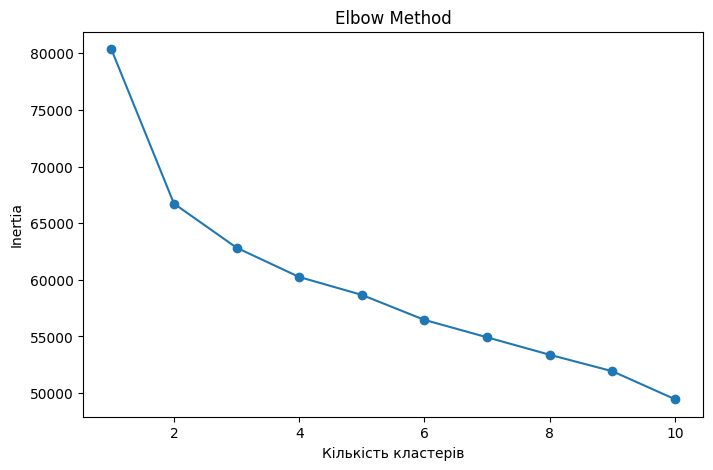

In [76]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.xlabel('Кількість кластерів')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

In [77]:
kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_final.fit(X_clean_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [83]:
df_clean = df_clean.copy()
df_clean['Final_Cluster'] = kmeans_final.labels_
df_clean['Final_Cluster'].value_counts()

,count
Final_Cluster,
2,1034
1,650
0,548


In [79]:
silhouette_final = silhouette_score(
    X_clean_scaled,
    kmeans_final.labels_
)

silhouette_final

np.float64(0.12625643618130966)

In [80]:
import plotly.express as px

fig = px.scatter_3d(
    df_clean,
    x='Income',
    y='Total_Spending',
    z='NumStorePurchases',
    color='Final_Cluster',
    title='Фінальна кластеризація клієнтів KMeans'
)

fig.show()

In [81]:
df_clean.groupby('Final_Cluster')[[
    'Income',
    'Total_Spending',
    'NumStorePurchases'
]].mean()

,Income,Total_Spending,NumStorePurchases
Final_Cluster,,,
0,76208.428832,1413.476277,8.385036
1,58076.946154,733.110769,7.769231
2,34553.186654,97.276596,3.209865


**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

In [85]:
Z = linkage(
    X_clean_scaled,
    method='single'
)

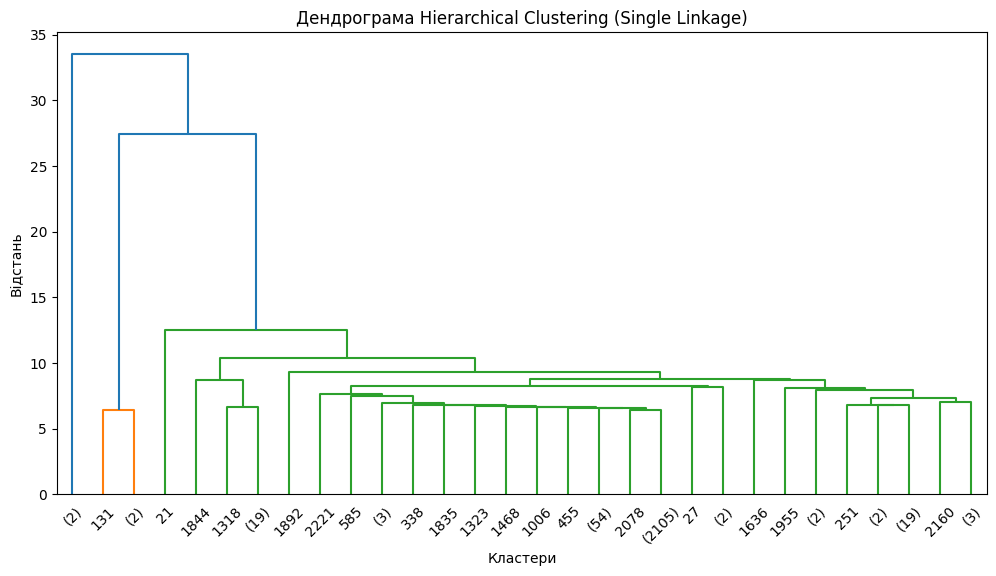

In [86]:
plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode='lastp',
    p=30
)

plt.title('Дендрограма Hierarchical Clustering (Single Linkage)')
plt.xlabel('Кластери')
plt.ylabel('Відстань')

plt.show()

In [87]:
cluster_2 = fcluster(
    Z,
    t=2,
    criterion='maxclust'
)

cluster_2[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [88]:
silhouette_2 = silhouette_score(
    X_clean_scaled,
    cluster_2
)

silhouette_2

np.float64(0.7676516051030264)

In [89]:
cluster_3 = fcluster(
    Z,
    t=3,
    criterion='maxclust'
)

cluster_3[:10]

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3], dtype=int32)

In [90]:
silhouette_3 = silhouette_score(
    X_clean_scaled,
    cluster_3
)

silhouette_3

np.float64(0.7214562743878733)

In [91]:
df_clean['Hierarchical_2'] = cluster_2
df_clean['Hierarchical_3'] = cluster_3

In [92]:
df_clean['Hierarchical_2'].value_counts()

,count
Hierarchical_2,
2,2230
1,2


In [93]:
df_clean['Hierarchical_3'].value_counts()

,count
Hierarchical_3,
3,2227
2,3
1,2


У результаті було виконано ієрархічну кластеризацію методом Single Linkage та побудовано дендрограму. За допомогою fcluster дані було розділено на 2 та 3 кластери. Значення silhouette score для 2 кластерів становить 0.767, а для 3 кластерів - 0.721, тому для даних краще підходить поділ на 2 кластери, оскільки він має вище значення якості кластеризації.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

In [94]:
kmeans = KMeans(n_clusters=3, random_state=42)

cluster_kmeans = kmeans.fit_predict(X_clean_scaled)

silhouette_kmeans = silhouette_score(
    X_clean_scaled,
    cluster_kmeans
)

silhouette_kmeans

np.float64(0.15450861983940592)

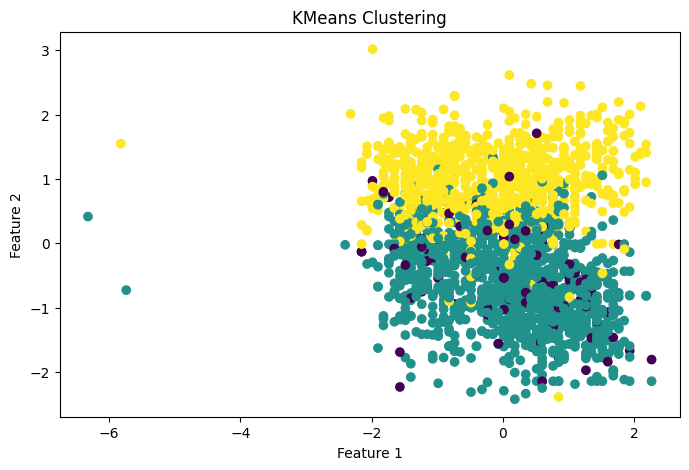

In [95]:
plt.figure(figsize=(8,5))

plt.scatter(
    X_clean_scaled[:,0],
    X_clean_scaled[:,1],
    c=cluster_kmeans
)

plt.title("KMeans Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

## Висновок
Для кластеризації було використано алгоритм KMeans з 3 кластерами. Значення silhouette score становить 0.155, що свідчить про слабке розділення кластерів. На графіку видно, що групи клієнтів частково перекриваються, тому отримана кластеризація не є ідеальною. Проте метод може бути корисним для попередньої сегментації клієнтів та пошуку загальних закономірностей у даних. Для покращення результату можна протестувати інші алгоритми або змінити кількість кластерів.